# Preprocessing & Augmentation (Phase 2)

This notebook validates the Phase 2 pipelines:
1. Albumentations transforms
2. PyTorch Dataset & DataLoader
3. Stratified splits

In [1]:
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split

# Fix CWD if run from notebooks/
if Path.cwd().name == 'notebooks':
    os.chdir('..')

# Import our custom modules
from src.augment import get_transforms
from src.dataset import MangoLeafDataset, ClimateYieldDataset

## 1. Image Data Pipeline

In [2]:
RAW_DIR = Path('data/raw')
REPORTS_DIR = Path('reports/figures')

# Get training transforms (heavy augmentation)
train_transforms = get_transforms(train=True)
val_transforms = get_transforms(train=False)

# Initialize Datasets
train_dataset = MangoLeafDataset(root_dir=RAW_DIR, transform=train_transforms)
val_dataset = MangoLeafDataset(root_dir=RAW_DIR, transform=val_transforms)

print(f"Total images found: {len(train_dataset)}")
print(f"Classes: {train_dataset.classes}")

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)

Total images found: 4000
Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']


/home/manas/Projects/mango-disease-prediction/.venv/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/home/manas/Projects/mango-disease-prediction/src/augment.py:33: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.2),
/home/manas/Projects/mango-disease-prediction/src/augment.py:41: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=16, max_width=16, min_holes=1, fill_value=0, p=0.2),


### Visualize Augmentations

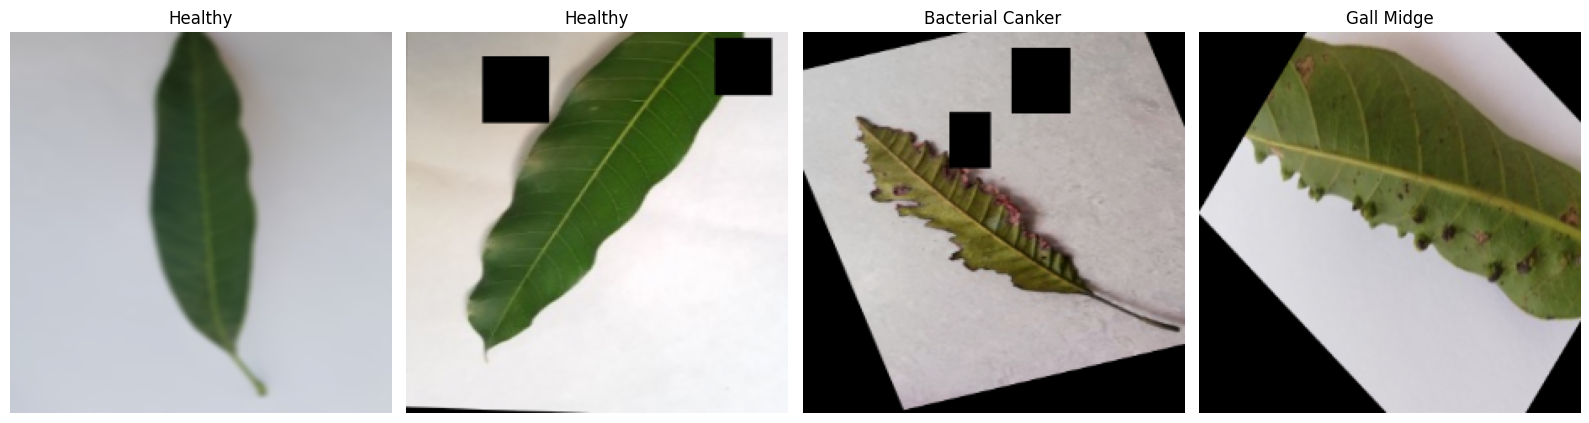

In [3]:
# Helper function to unnormalize and show image
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# Get a batch of training data
images, labels = next(iter(train_loader))

plt.figure(figsize=(16, 8))
for i in range(4):
    plt.subplot(1, 4, i+1)
    imshow(images[i], title=train_dataset.classes[labels[i]])

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'augmented_batch.png')

## 2. Tabular Pipeline

In [4]:
climate_dataset = ClimateYieldDataset(csv_path='data/processed/tabular_schema.csv', is_train=True)
climate_loader = DataLoader(climate_dataset, batch_size=4, shuffle=True)

x_batch, y_batch = next(iter(climate_loader))
print("Climate Batch Features (Normalized):")
print(x_batch)
print("\nYield Batch Labels:")
print(y_batch)

Climate Batch Features (Normalized):
tensor([[-0.6014, -0.9084, -0.1734, -0.2317, -0.2714],
        [ 0.4801, -0.0680, -0.8673, -1.0984,  0.5783],
        [ 1.2004, -0.8629, -1.3349, -1.5308,  1.7616],
        [-2.0362, -1.2174,  2.3329,  2.0073, -1.7660]])

Yield Batch Labels:
tensor([7.4200, 6.3100, 5.2500, 7.3600])
